Target rho      : 0.80
Observed rho    : 0.796
Difference      : 0.004


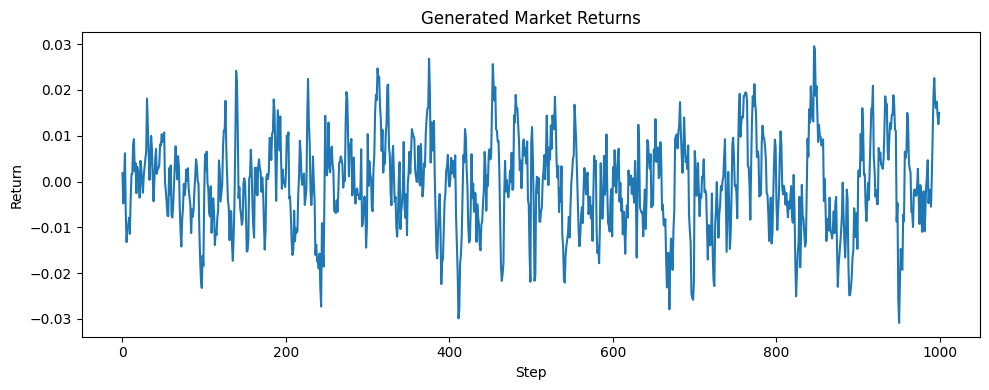

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from week5_trading_env_v3 import TradingEnvV3


def collect_returns(rho=0.8, n_steps=1000):

    env = TradingEnvV3(rho=rho)

    env.reset(seed=42)

    returns = []

    done = False

    while len(returns) < n_steps:

        action = env.action_space.sample()

        obs, reward, terminated, truncated, info = env.step(action)

        returns.append(info["return"])

        if terminated or truncated:

            env.reset()

    env.close()

    return np.array(returns)


def lag1_autocorrelation(x):

    x1 = x[:-1]

    x2 = x[1:]

    return np.corrcoef(x1, x2)[0, 1]


def plot_returns(returns):

    plt.figure(figsize=(10,4))

    plt.plot(returns)

    plt.title("Generated Market Returns")

    plt.xlabel("Step")

    plt.ylabel("Return")

    plt.tight_layout()

    plt.show()


if __name__ == "__main__":

    rho = 0.8

    returns = collect_returns(rho=rho)

    autocorr = lag1_autocorrelation(returns)

    print(f"Target rho      : {rho:.2f}")

    print(f"Observed rho    : {autocorr:.3f}")

    print(f"Difference      : {abs(rho-autocorr):.3f}")

    plot_returns(returns)